# Task 1: Import Libraries

In [1]:
# math and stats
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression, LinearRegression

# graphs
import graphviz
import networkx as nx

# dataviz
import matplotlib.pyplot as plt
import seaborn as sns

# causality
from dowhy import CausalModel
from castle.algorithms import PC
from castle.common.priori_knowledge import PrioriKnowledge

# other tools
import pandas as pd
from IPython.display import display_png

2026-05-05 00:40:49,284 - /usr/local/lib/python3.9/dist-packages/castle/backend/__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).
2026-05-05 00:40:49,385 - /usr/local/lib/python3.9/dist-packages/castle/algorithms/__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


# Task 2: Load the Dataset

In [2]:
# Load the dataset
data = pd.read_csv("usercode/data.csv")
# Print the first five rows of the dataset
data.head()

,treat,age,hisp,black,married,educ,nodegr,re19,re20,re22
0,1,29,0,0,1,13.0,0,28221,28072,44686
1,0,48,0,1,0,8.0,1,38135,38674,43367
2,1,21,0,0,1,9.0,0,27193,27913,41550
3,0,50,0,0,0,12.0,1,41695,42696,38669
4,1,49,1,0,0,10.8,0,25159,24935,47043


# Task 3: Explore the Dataset

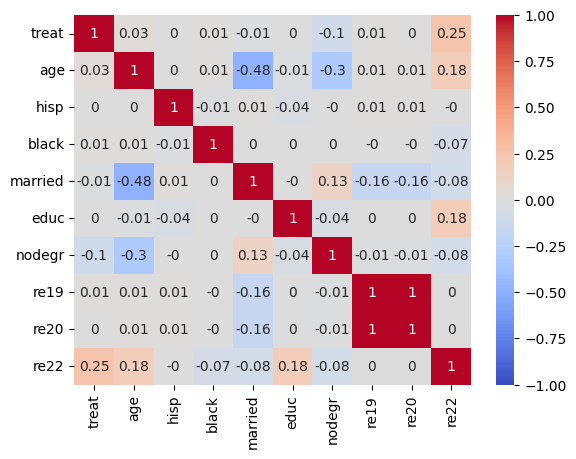

array([[<Axes: xlabel='treat', ylabel='treat'>,
        <Axes: xlabel='age', ylabel='treat'>,
        <Axes: xlabel='hisp', ylabel='treat'>,
        <Axes: xlabel='black', ylabel='treat'>,
        <Axes: xlabel='married', ylabel='treat'>,
        <Axes: xlabel='educ', ylabel='treat'>,
        <Axes: xlabel='nodegr', ylabel='treat'>,
        <Axes: xlabel='re19', ylabel='treat'>,
        <Axes: xlabel='re20', ylabel='treat'>,
        <Axes: xlabel='re22', ylabel='treat'>],
       [<Axes: xlabel='treat', ylabel='age'>,
        <Axes: xlabel='age', ylabel='age'>,
        <Axes: xlabel='hisp', ylabel='age'>,
        <Axes: xlabel='black', ylabel='age'>,
        <Axes: xlabel='married', ylabel='age'>,
        <Axes: xlabel='educ', ylabel='age'>,
        <Axes: xlabel='nodegr', ylabel='age'>,
        <Axes: xlabel='re19', ylabel='age'>,
        <Axes: xlabel='re20', ylabel='age'>,
        <Axes: xlabel='re22', ylabel='age'>],
       [<Axes: xlabel='treat', ylabel='hisp'>,
        <Axes: xlab

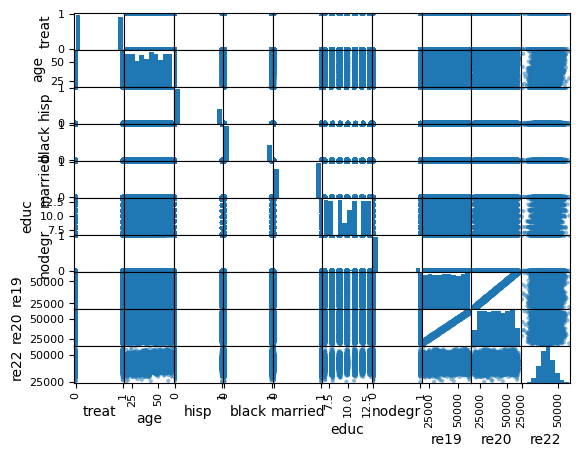

In [3]:
# Check for the missing values
data.isna().sum()
# Print a concise summary of the DataFrame
data.describe()
# Create a correlation matrix
correlation_matrix = data.corr().round(2)
# Plot a heatmap to visualize the correlation
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()
# Plot the scatter matrix
pd.plotting.scatter_matrix(data)

# Task 4: Build Causal Graphical Models using DAGs

In [4]:
# Create a dictionary that maps numbers to the names of variables and its inverse
mapping = {k: v for k, v in zip(range(len(list(data))), list(data))}
inverse_mapping = {v: k for k, v in mapping.items()}

# Instantiate and encode priori knowledge
priori_knowledge = PrioriKnowledge(len(list(data)))
required_edges = [
    ('educ', 're22'),
    ('age', 're22'),
    ('nodegr', 're22')
    ]
required_edges=[(inverse_mapping[edge[0]], inverse_mapping[edge[1]]) for edge in required_edges]
forbidden_edges = [
    ('treat', 're19'),
    ('treat', 're20'),
    ('black', 'hisp'),
    ('black', 'age'),
    ('age', 'black'),
    ('hisp', 'black'),
    ('educ', 'black'),
    ('educ', 'hisp'),
    ('re22', 're19'),
    ('re22', 're20'),
    ('re20', 're19'),
    ('treat', 'nodegr')
    ]
forbidden_edges=[(inverse_mapping[edge[0]], inverse_mapping[edge[1]]) for edge in forbidden_edges]

priori_knowledge.add_required_edges(required_edges)
priori_knowledge.add_forbidden_edges(forbidden_edges)

# Learn the causal graph using the PC algorithm
pc = PC(priori_knowledge=priori_knowledge)
pc.learn(data)

# Get the predicted causal matrix and convert it to a directed graph
pred_dag = pc.causal_matrix
g_pred = nx.DiGraph(pred_dag)
g_pred = nx.relabel_nodes(g_pred, mapping, copy=True)

# Task 5: Identify Confounders and Colliders

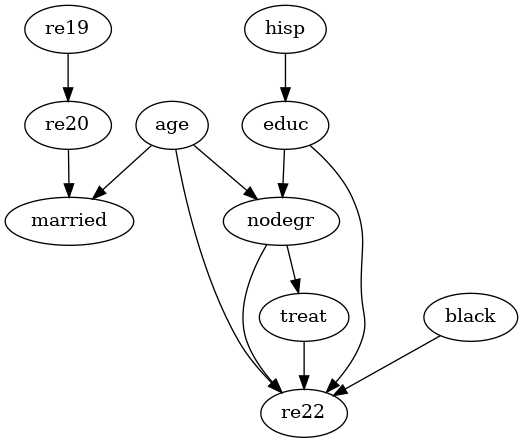

In [5]:
# Create a graph:
dag = graphviz.Digraph()
for edge in g_pred.edges:
    dag.edge(edge[0],edge[1])
display_png(dag)

# List variables to control for
variables=['treat','nodegr','black', 'age', 'educ']

# Task 6: Linear Regression for Causal Inference

In [6]:
# Select the right variables:
X = data[variables]

# Perform a linear regression:
X = sm.add_constant(X)
y = data['re22']

model = sm.OLS(y,X)
results = model.fit()

# Print a model summary:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   re22   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     300.4
Date:                Tue, 05 May 2026   Prob (F-statistic):          1.87e-300
Time:                        00:41:58   Log-Likelihood:                -97193.
No. Observations:               10000   AIC:                         1.944e+05
Df Residuals:                    9994   BIC:                         1.944e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.538e+04    251.278    140.797      0.0

# Task 7: Use Instrumental Variables to Measure Causality

In [7]:
# Perform a linear regression on `re22` as a function of `hisp`
X = data['hisp']
X = sm.add_constant(X)
y = data['re22']

model = sm.OLS(y,X)
results = model.fit()
coef1 = results.params['hisp']

# Perform a linear regression on `re22` as a function of `educ`
X = data['educ']
X = sm.add_constant(X)
y = data['re22']

model = sm.OLS(y,X)
results = model.fit()
coef2 = results.params['educ']

# Get the ratio between the two coefficients
coef3 = coef1/coef2
print(coef3)

-0.11305040636883229


# Task 8: Distance Matching

In [8]:
# Generate the graph
nodes = list(g_pred.nodes)
edges = list(g_pred.edges)
gml_string = 'graph [directed 1\n'
for node in nodes:
    gml_string += f'\tnode [id "{node}" label "{node}"]\n'
for edge in edges:
    gml_string += f'\tedge [source "{edge[0]}" target"{edge[1]}"]\n'
gml_string += ']'

# Create the model
model = CausalModel(
    data=data,
    treatment='treat',
    outcome='re22',
    graph=gml_string
)

# Get the estimand
estimand = model.identify_effect()

# Get the estimate (distance matching)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.distance_matching',
    target_units='ate'
    )

print(estimate.value)

2026-05-05 00:42:25,761 - /usr/local/lib/python3.9/dist-packages/dowhy/causal_model.py[line:480] - INFO: Model to find the causal effect of treatment ['treat'] on outcome ['re22']
2026-05-05 00:42:25,771 - /usr/local/lib/python3.9/dist-packages/dowhy/causal_identifier/auto_identifier.py[line:727] - INFO: Causal effect can be identified.
2026-05-05 00:42:25,779 - /usr/local/lib/python3.9/dist-packages/dowhy/causal_identifier/auto_identifier.py[line:244] - INFO: Instrumental variables for treatment and outcome:[]
2026-05-05 00:42:25,781 - /usr/local/lib/python3.9/dist-packages/dowhy/causal_identifier/auto_identifier.py[line:259] - INFO: Frontdoor variables for treatment and outcome:[]
2026-05-05 00:42:25,784 - /usr/local/lib/python3.9/dist-packages/dowhy/causal_model.py[line:308] - INFO: distance_matching
2026-05-05 00:42:25,794 - /usr/local/lib/python3.9/dist-packages/dowhy/causal_estimators/distance_matching_estimator.py[line:101] - INFO: INFO: Using Distance Matching Estimator
2026-05

-1026.3381


# Task 9: Propensity Score

In [9]:
# Get estimate (Stratification)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.propensity_score_stratification',
    target_units='ate'
    )
print(estimate.value)

# Get estimate (Matching)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.propensity_score_matching',
    target_units='ate'
    )
print(estimate.value)

# Get estimate (Weighting)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.propensity_score_weighting',
    target_units='ate'
    )
print(estimate.value)

2026-05-05 00:42:39,394 - /usr/local/lib/python3.9/dist-packages/dowhy/causal_model.py[line:308] - INFO: propensity_score_stratification
2026-05-05 00:42:39,401 - /usr/local/lib/python3.9/dist-packages/dowhy/causal_estimators/propensity_score_stratification_estimator.py[line:88] - INFO: Using Propensity Score Stratification Estimator
/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check

2121.1327843698787


2026-05-05 00:42:43,605 - /usr/local/lib/python3.9/dist-packages/dowhy/causal_model.py[line:308] - INFO: propensity_score_weighting
2026-05-05 00:42:43,608 - /usr/local/lib/python3.9/dist-packages/dowhy/causal_estimators/propensity_score_weighting_estimator.py[line:96] - INFO: INFO: Using Propensity Score Weighting Estimator
2026-05-05 00:42:43,614 - /usr/local/lib/python3.9/dist-packages/dowhy/causal_estimators/propensity_score_weighting_estimator.py[line:120] - INFO: b: re22~treat+nodegr


1344.1307
2121.355943980445


# Task 10: Calculate Doubly-Robust Estimations

In [10]:
# Get an effect estimation using a doubly robust learner
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dr.LinearDRLearner',
    target_units='ate',
    method_params={
        'init_params': {
            'model_propensity': LogisticRegression(),
            'model_regression': LinearRegression()
        },
        'fit_params': {}
    })

print(estimate.value)

/usr/local/lib/python3.9/dist-packages/shap/utils/_clustering.py:35: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _pt_shuffle_rec(i, indexes, index_mask, partition_tree, M, pos):
/usr/local/lib/python3.9/dist-packages/shap/utils/_clustering.py:54: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def delta_minimization_order(all_masks, max_swap_size=100, num_pa

2126.4956823058606


is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
is_sparse is deprecated and will be removed in a future version. Check `

# Task 11: Use the Difference-in-Differences (DID) Technique

In [11]:
(
    data.groupby('treat') # Grouping the data by the treatment variable

        [['re20','re22']].mean() # Getting the mean of `re20` and the mean of `re22`

        .diff(axis=1)['re22'] # Calculating the difference between the two means for each treatment group

        .diff()[1] # Calculating the difference between the two differences
)

# Task 12: Causal Forests

In [12]:
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dml.CausalForestDML',
    target_units='ate',
    method_params={
        'init_params': {
            'model_y': LinearRegression(),
            'model_t': LogisticRegression(),
            'discrete_treatment': True,
            'cv': 5
        },
        'fit_params': {
        }
    }
)

print(estimate.value)

2026-05-05 00:43:28,229 - /usr/local/lib/python3.9/dist-packages/dowhy/causal_estimators/econml.py[line:105] - INFO: INFO: Using EconML Estimator
2026-05-05 00:43:28,236 - /usr/local/lib/python3.9/dist-packages/dowhy/causal_estimators/econml.py[line:173] - INFO: b: re22~treat+nodegr | black
is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
is_sparse is

2136.2908901839537
